<a href="https://colab.research.google.com/github/musaadamukhs/Marketing-ROI-Linear-Regression/blob/main/marketing_regression_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from scipy import stats

# 1. Load data
df = pd.read_csv("marketing_and_sales_data_evaluate_lr.csv")

# 2. Basic exploration
print(df.info())
print(df.describe())

# 3. Handle missing values (if any)
df = df.dropna()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 4 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   TV            4562 non-null   float64
 1   Radio         4568 non-null   float64
 2   Social_Media  4566 non-null   float64
 3   Sales         4566 non-null   float64
dtypes: float64(4)
memory usage: 143.0 KB
None
                TV        Radio  Social_Media        Sales
count  4562.000000  4568.000000   4566.000000  4566.000000
mean     54.066857    18.160356      3.323956   192.466602
std      26.125054     9.676958      2.212670    93.133092
min      10.000000     0.000684      0.000031    31.199409
25%      32.000000    10.525957      1.527849   112.322882
50%      53.000000    17.859513      3.055565   189.231172
75%      77.000000    25.649730      4.807558   272.507922
max     100.000000    48.871161     13.981662   364.079751


TV              0.999497
Radio           0.868638
Social_Media    0.527446
Sales           1.000000
Name: Sales, dtype: float64


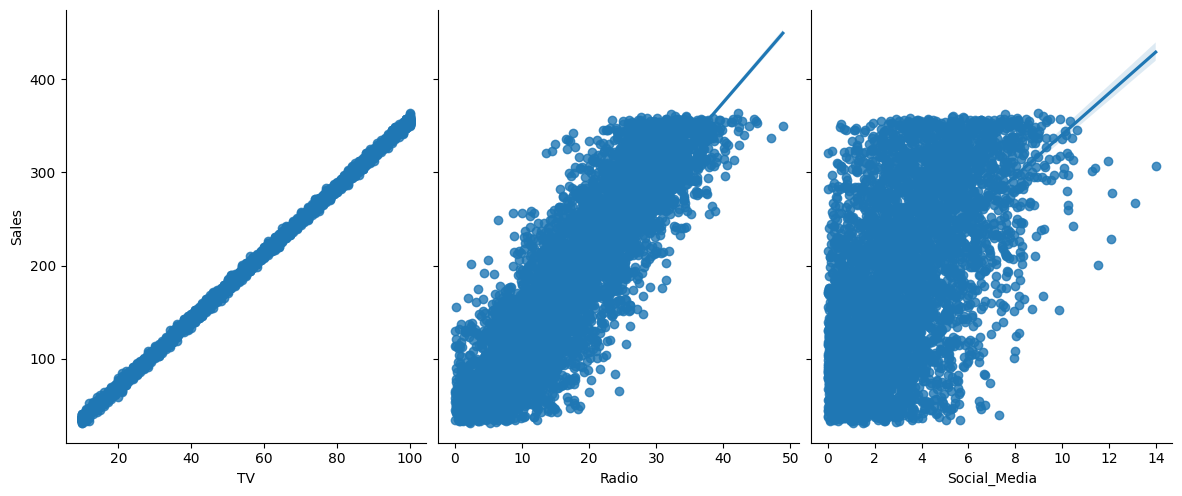

In [8]:
correlation_matrix = df[['TV', 'Radio', 'Social_Media', 'Sales']].corr()
print(correlation_matrix['Sales'])

# Visualize the relationships
sns.pairplot(df, x_vars=['TV', 'Radio', 'Social_Media'], y_vars='Sales', height=5, aspect=0.8, kind='reg')
plt.show()

In [9]:
# Define Independent (X) and Dependent (y) variables
# Let's assume 'TV' was your highest correlated variable
X = df['TV']
y = df['Sales']

# statsmodels needs an explicit intercept (constant) term added
X_with_constant = sm.add_constant(X)

# Fit Ordinary Least Squares (OLS) model
model = sm.OLS(y, X_with_constant).fit()

# Print the comprehensive summary
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:                  Sales   R-squared:                       0.999
Model:                            OLS   Adj. R-squared:                  0.999
Method:                 Least Squares   F-statistic:                 4.517e+06
Date:                Sat, 30 May 2026   Prob (F-statistic):               0.00
Time:                        07:55:08   Log-Likelihood:                -11366.
No. Observations:                4546   AIC:                         2.274e+04
Df Residuals:                    4544   BIC:                         2.275e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.1325      0.101     -1.317      0.1

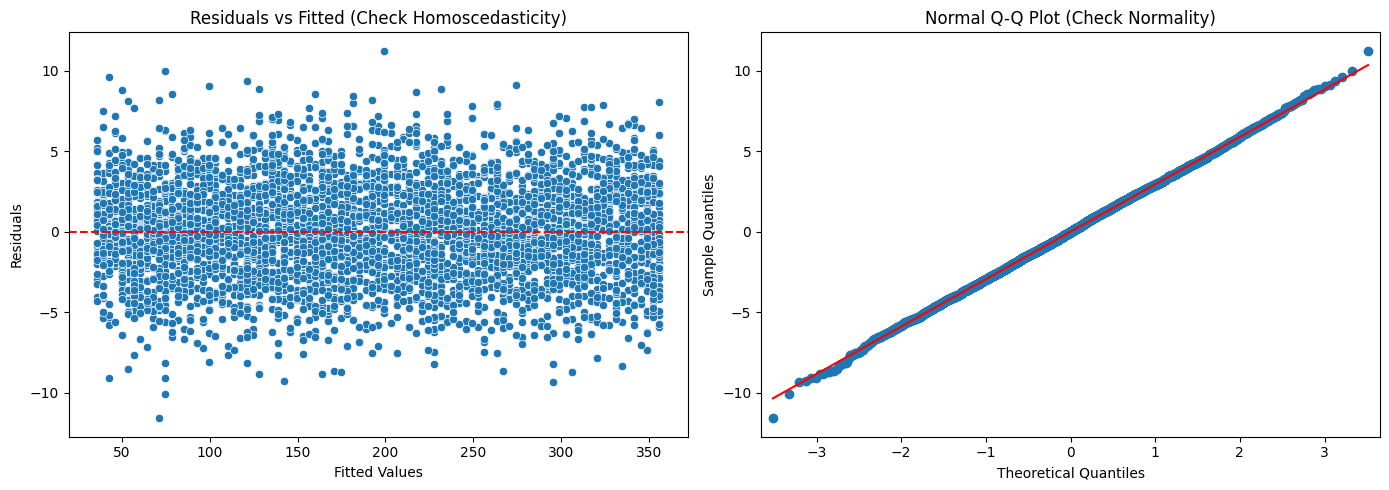

In [10]:
# Extract residuals and predicted values
fitted_values = model.predict(X_with_constant)
residuals = model.resid

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Linearity & Homoscedasticity check (Residuals vs Fitted)
sns.scatterplot(x=fitted_values, y=residuals, ax=axes[0])
axes[0].axhline(y=0, color='r', linestyle='--')
axes[0].set_title('Residuals vs Fitted (Check Homoscedasticity)')
axes[0].set_xlabel('Fitted Values')
axes[0].set_ylabel('Residuals')

# 2. Normality check (Q-Q Plot)
sm.qqplot(residuals, line='s', ax=axes[1])
axes[1].set_title('Normal Q-Q Plot (Check Normality)')

plt.tight_layout()
plt.show()

R-squared ($R^2$): Explains how much variance in Sales is explained by your marketing channel. (e.g., "An $R^2$ of 0.85 means 85% of the variation in Sales is explained by our TV advertising budget.")Coefficient ($\beta_1$): The slope of the line. (e.g., "For every $1 increase in TV ad spend, Sales are expected to increase by $X.")P-value ($P > |t|$): If this is $< 0.05$, the relationship is statistically significant, meaning the marketing channel genuinely impacts sales and isn't just a fluke in the data.